In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
trade_history = pd.read_csv('data/processed.csv')

<Axes: >

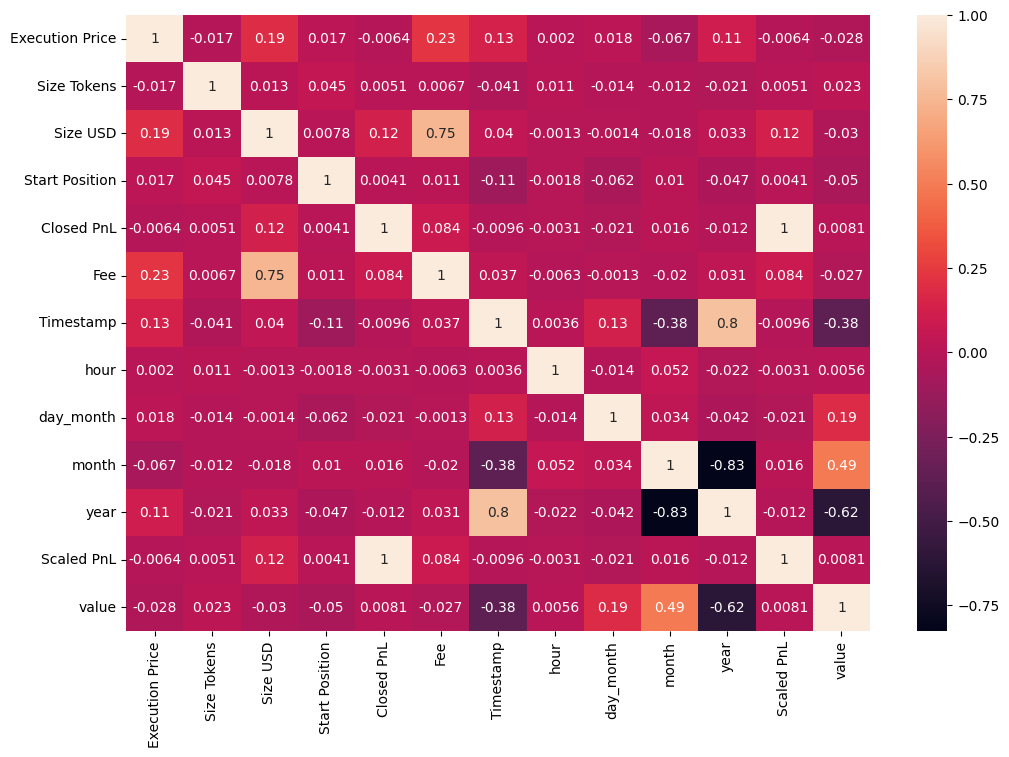

In [3]:
numeric = trade_history.select_dtypes(include='number').drop(['Order ID','Trade ID'],axis=1)

corr = numeric.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True)

## Correlation with Sentiment
Mainly looking at the 'value' (sentiment) for patterns
- No relation between Closed PnL and Sentiment value.
- Weak inverse relation between Sentiment Value and Start position, Execution price, Size USD
- No direct relation between market sentiment and Closed PnL

As the sentiment value (Greed) increases the average Start position price, execution price, and Size USD decreases, this in turn could mean more people going short in order to make profit.
- moderate correlation between month and sentiment value
- moderate inverse correlation between year and sentiment value
- weak correlation between day of month and sentiment

These indicate partial cyclic behaviour within the sentiments trends

## Sentiment vs Trading Direction

In [4]:
cross = pd.crosstab(
    trade_history['Direction'],
    trade_history['classification'],
    normalize='index'
)

# sns.heatmap(cross, annot=True, cmap='Blues')
cross

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
Direction,,,,,
Auto-Deleveraging,0.000000,0.000000,0.000000,1.000000,0.000000
Buy,0.048277,0.307011,0.191852,0.280270,0.172589
Close Long,0.128210,0.147623,0.354575,0.164304,0.205288
Close Short,0.086567,0.180437,0.256089,0.314439,0.162468
Liquidated Isolated Short,0.000000,0.000000,0.000000,1.000000,0.000000
Long > Short,0.087719,0.122807,0.245614,0.280702,0.263158
Open Long,0.140395,0.126265,0.357230,0.171240,0.204870
Open Short,0.079867,0.192824,0.273949,0.293500,0.159860
Sell,0.052357,0.359964,0.169028,0.300774,0.117878


## Key Insights:

- `Fear` and `Greed` dominated trading activity across most directions:
  - `Open Long`: 35.7% Fear
  - `Open Short`: 29.3% Greed
  - `Buy`: 28.0% Greed
  - `Sell`: 30.1% Greed

- `Extreme Greed` showed the highest speculative participation:
  - `Buy`: 30.7%
  - `Sell`: 36.0%

- Long positions were frequently opened during fearful conditions:
  - `Open Long`: 35.7% Fear
  - `Close Long`: 35.5% Fear

- Short-related activity increased during greedy conditions:
  - `Open Short`: 29.3% Greed
  - `Close Short`: 31.4% Greed

- Neutral sentiment contributed relatively low participation:
  - `Buy`: 17.3% Neutral
  - `Sell`: 11.8% Neutral
  - `Open Short`: 16.0% Neutral

- Liquidation and deleveraging events occurred entirely during `Greed`:
  - `Auto-Deleveraging`: 100% Greed
  - `Liquidated Isolated Short`: 100% Greed
  - `Settlement`: 100% Greed

- Sentiment-driven behavior was evident across nearly all trading actions, indicating strong emotional and momentum-based market participation.

In [5]:
trade_volumne = trade_history.groupby('classification').agg({
    'Size USD': ['sum', 'mean'],
    'Closed PnL': ['sum', 'mean'],
    'Trade ID': 'count'
})

trade_volumne

Size USD                 Closed PnL            Trade ID
                         sum         mean           sum       mean    count
classification                                                             
Extreme Fear    1.144843e+08  5349.731843  7.391102e+05  34.537862    21400
Extreme Greed   1.244652e+08  3112.251565  2.715171e+06  67.892861    39992
Fear            4.833248e+08  7816.109931  3.357155e+06  54.290400    61837
Greed           2.885825e+08  5736.884375  2.150129e+06  42.743559    50303
Neutral         1.802421e+08  4782.732661  1.292921e+06  34.307718    37686

## Key Insights: Trade Volume and Profitability by Sentiment

- `Fear` generated the highest trading volume at **$483.3M** across **61,837 trades**.
- `Fear` also had the highest average trade size at **$7,816 per trade**.
- `Extreme Greed` achieved the highest average pnl at **$67.89 per trade**.
- `Greed` accounted for **50,303 trades** with a total trading volume of **$288.6M**.
- `Extreme Fear` showed the lowest participation with only **21,400 trades**.
- Aggregate pnl remained positive across all sentiment regimes despite many negative pnl trades.
- The pnl distribution was highly skewed, indicating large profitable outlier trades dominated cumulative returns.
- Trading participation and capital deployment increased significantly during emotionally charged market conditions.

In [6]:
sentiment = pd.read_csv('data/fear_greed_index.csv')
sentiment_day_after = sentiment.sort_values('date')
sentiment_day_after['next_sentiment'] = (
    sentiment_day_after['classification'].shift(-1)
)
transition_counts = pd.crosstab(
    sentiment_day_after['classification'],
    sentiment_day_after['next_sentiment']
)

transition_counts

next_sentiment,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
classification,,,,,
Extreme Fear,416,0,88,0,4
Extreme Greed,0,271,2,52,1
Fear,88,1,610,12,70
Greed,1,54,12,498,67
Neutral,3,0,68,71,254


## Key Insights: Sentiment Transition Analysis

- `Fear → Fear` showed the highest persistence with **247 transitions**, indicating strong bearish sentiment continuation.
- `Fear → Greed` occurred **198 times**, showing frequent recovery shifts from bearish to bullish sentiment.
- `Greed → Fear` occurred **190 times**, suggesting high emotional volatility and rapid market reversals.
- `Extreme Fear → Greed` recorded **142 transitions**, indicating strong rebound behavior after panic conditions.
- `Greed → Greed` persisted only **130 times**, significantly lower than `Fear → Fear`, implying bullish sentiment was less stable.
- `Extreme Greed → Fear` occurred **146 times**, showing optimistic conditions frequently transitioned into bearish sentiment.
- `Neutral → Greed` transitions (**124**) were higher than `Neutral → Extreme Greed` (**55**), indicating gradual bullish sentiment formation.
- `Neutral → Fear` occurred **89 times**, suggesting neutral conditions were more likely to weaken into bearish sentiment than strengthen into extreme bullishness.
- Sentiment transitions were highly dynamic, with substantial cross-movement between Fear and Greed states rather than long-term persistence.
- The market exhibited strong emotional regime switching behavior, indicating elevated sentiment-driven volatility.